![logo](img/logoitqv1.jpg)
<br>

# 1 Ejercicio Ejercicio Practico


<br>

![python](img/python_logo.png)

<br>

**Nombre:** *Alexis González*    **Fecha:** *20/07/2026*

<br>

[link de Git Hub](https://github.com/Mathias255/Machine-E-learning.git)

**2 Práctica Académica**

**2.1 Normalización y Estandarización de Datos en Inteligencia Artificial**

**3 Análisis y aplicación de técnicas de normalización y estandarización en conjunto de datos para modelos de aprendizaje
automático**

**3.0.1 Objetivo General**

Aplicar Técnicas de normalización y estandarización de datos mediante herramientas de python, con
el fin de comprender su impacto en la prepación de datos y en el desempeño de modelos de aprendizaje automático. ### Objetivos especificos * Identificar diferencias de escala entre variables
numércias. * Aplicar técnicas de normalización (Min-Max) * Aplicar técnicas de estandarización
(Z-score) * Analizar la importancia del preprocesaminto en modelos de IA ### Antecedentes
/Fundamentación teórica En el contexto del aprendizaje automático, los algoritmos suelen verse
afectados por la escala de los datos. Variables con valores grandes pueden dominar el comportamiento del modelo, generando sesgos y resultados pocos conficables. Para mitigar este problema,
se emplea técnicas como: * Normalización: transforma los datos a un rango especifico (generalmente[0,1]) * Estandarización: ajusta los datos para que tengan mdia 0 y desviación estandar
1. Estas técnicas son fundamentales en algoritmos como: * KNN * Regresión logística * Redes
neuronales ### Escenario de práctica Una empresa de análisis de datos desea desarrollar modelos
predictivos utilizando información de clientes. Sin embargo, se ha identificado que las variables
presentan diferentes escalas, lo que puede afectar el rendimiento de los modelos. Se soliciata al
analista aplicar tecnicas de preprocesamiento y limpieza de datos para mejorar la calidad de lso
1
datos. ## Conjunto de datos utilizar Dataset 1(Conceptual): Iris dataset Dataset 2 (aplicación
real): California Housing Dataset


In [1]:
 #Importacion de librerias
import pandas as pd
import numpy as np
#from sklearn.datasets import load_iris
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing

In [1]:
#Configuramos el entorno de descarga
import os
os.environ['KAGGLE_CONFIG_DIR']="C:/Users/mathi/.kaggle"

In [5]:
#Creamos la carpeta dataset
os.makedirs("dataset", exist_ok=True)

In [6]:
#Descargamos el dataset
!kaggle datasets download -d uciml/iris

Dataset URL: https://www.kaggle.com/datasets/uciml/iris
License(s): CC0-1.0




  0%|          | 0.00/3.60k [00:00<?, ?B/s]
100%|##########| 3.60k/3.60k [00:00<00:00, 1.22MB/s]


In [8]:
#Descompriminos el archivo
with zipfile.ZipFile("iris.zip", 'r') as zip_ref:
       zip_ref.extractall("dataset")

In [9]:
#Cargamos el conjunto de datos
df = pd.read_csv("dataset/Iris.csv")

In [10]:
#mostramos el conjunto de datos"
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [11]:
#Eliminamos columnas innecesarias en la limpieza de datos como vemos en el dataframe la columna id no aporta
#nada a nuestro modelo por lo tanto lo eliminamos
if 'Id' in df.columns:
    df=df.drop(columns=["Id"])

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [12]:
 #Mostramos los detalles de nuesto dataset
df.info()
#Vrificamos si tenemos datos nulos si lo tenemos lo sumamos
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [13]:
#Separamos los datos de entrada con nuestra variable objetivo
X=df.drop(columns=['Species'])
y=df['Species']

In [14]:
#Exploramos o generamos un analis exploratorio del conjutno de datos
X.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


**3.0.2 Conclusión**

Cuando observamso la tabla, lo primero que se observa es que cada variable tiene valores diferentes
en tamaño y rango Por ejemplo * PetalLengthCm tiene valores desde 1.0 hasta 6.9, lo que significa
que varia bastante * En cambio, SepalWidthCm va aproximadamente de 2.0 a 4.4 es decir, tiene
meno variación. Esto nos dice que no todas las variables están en la misma escala. ### Qué
significa? Al ver los datos vemos que algunas variables tiene números más grandes que otras, y
en modelos como KNN. * Los números grandes “pesan más” * Influyen mas en el resultado. Sino
hacemos nada y trabajamos con estos datos el mnodelo va a tomas decisiones basadas en el argumeto
PetalLengtnCm y menos en otras variables.Esto no es lo conveniento y a esto lo llamamos sesgo.
Para no tener sesgo dentro de nuestros datos lo que hacemso es: * Normalización * Estandarización
Esto permite que las variables esten en la misma celda y tengan la misma importancia.

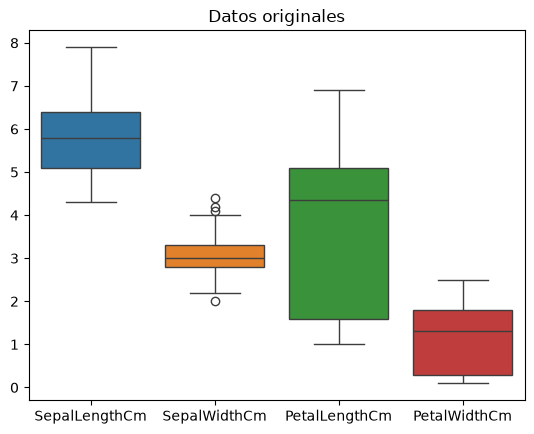

In [15]:
#dibujamso los datos originales
sns.boxplot(data=X)
#Ponemos un titulo a la imagen
plt.title("Datos originales")
plt.show()

**3.1 Interpretación de la imagen**

Este gráfico nos permite observar que los datos no están en la misma escala y que algunas variables
tienen mayor variabilidad que otras. Esto puede afectar el comportamiento de los modeos de
inteligencia artifical, por lo que es necesario aplicar técnicas como la normalización o estandarización
para equilibrar la influencia de todas las varaibles.


In [16]:
 #Normalizamos el conjunto de datos
normalizer = preprocessing.MinMaxScaler()
X_norm=normalizer.fit_transform(X)
X_norm = pd.DataFrame(X_norm, columns=X.columns)
X_norm.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667


In [17]:
X_norm.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,0.428704,0.439167,0.467571,0.457778
std,0.230018,0.180664,0.299054,0.317984
min,0.000000,0.000000,0.000000,0.000000
25%,0.222222,0.333333,0.101695,0.083333
50%,0.416667,0.416667,0.567797,0.500000
75%,0.583333,0.541667,0.694915,0.708333
max,1.000000,1.000000,1.000000,1.000000


In [18]:
#Estaddarización
standarizer = preprocessing.StandardScaler()
#Estandarizamos los datos
X_std=standarizer.fit_transform(X)
X_std= pd.DataFrame(X_std, columns=X.columns)
X_std.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977


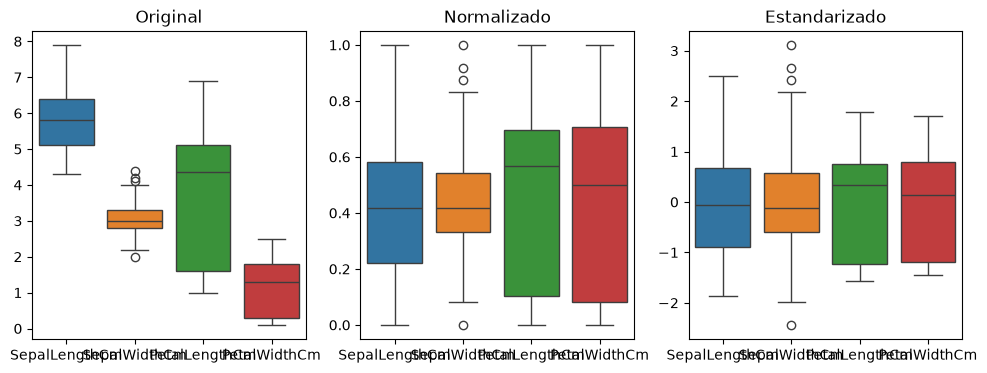

In [19]:
#Comporación visual
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.boxplot(data=X)
plt.title("Original")

plt.subplot(1,3,2)
sns.boxplot(data=X_norm)
plt.title("Normalizado")

plt.subplot(1,3,3)
sns.boxplot(data=X_std)
plt.title("Estandarizado")

plt.show()
